# Analysis of datasets from UCI and openML

Companion to `00-analysis-of-datasets.ipynb` for the datasets added to the research in addition to the imbalanced-learn / KEEL benchmark. Two groups:

- **Hard**: features overlap the classes, so a standard ensemble struggles — `diabetes130`, `default_credit`, `secom`.
- **Imbalanced**: strong signal but a rare positive class — `htru2`, `creditcard`.

We look at size, number of features, class imbalance, categorical variables, missing data, and feature distributions.

In [1]:
import sys
sys.path.insert(1, '../../')

In [2]:
import zipfile
from io import BytesIO
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_engine.selection import DropConstantFeatures
from feature_engine.variable_handling import find_categorical_variables

from sklearn.datasets import fetch_openml

from ucimlrepo import fetch_ucirepo

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

## Load data

In [4]:
datasets = {
    "diabetes130": 296, 
    "default_credit": 350, 
    "htru2": 372,
    "credit_fraud":1597,
    "sencom": None,
}

In [5]:
def load_data(dataset):
    if dataset == "credit_fraud":
        data = fetch_openml(data_id=1597, as_frame=True)
        X = data.data.copy()
        y = data.target.copy().astype(int)
        
    elif dataset == "sencom":
        # SECOM is not available through the ucimlrepo API, so we download it
        #  directly from the UCI static file server.
        SECOM_URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"
        with urlopen(SECOM_URL) as resp:
            archive = zipfile.ZipFile(BytesIO(resp.read()))
        with archive.open("secom.data") as f:
            X = pd.read_csv(f, sep=r"\s+", header=None, na_values="NaN")
        with archive.open("secom_labels.data") as f:
            labels = pd.read_csv(f, sep=r"\s+", header=None)
        X.columns = [f"feature_{i}" for i in range(X.shape[1])]
        y = labels.iloc[:, 0]  # -1 = pass, 1 = fail; timestamp column is dropped

    else:
        data = fetch_ucirepo(id=datasets[dataset])
        X = data.data.features.copy()
        y = data.data.targets.copy()

    if dataset == "diabetes130":
        y = (y.iloc[:, 0] == "<30").astype(int).to_numpy()
    
    return X, y

In [6]:
X, y = load_data("credit_fraud")
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


## Data imbalance

In [7]:
ir = []
data_size = []
n_features = []
n_minority = []

# class imbalance for each imbalanced-learn dataset

for dataset in datasets.keys():
    X, y = load_data(dataset)
    maj_, min_ = np.unique(y, return_counts=True)[1]
    ir.append(np.round(maj_/min_, 1))
    data_size.append(len(X))
    n_features.append(X.shape[1])
    n_minority.append(np.sum(y == 1))


data_df = pd.concat([
    pd.Series(ir),
    pd.Series(data_size),
    pd.Series(n_features),
    pd.Series(n_minority),
], axis=1)

data_df.columns = ["ir", "data_size", "n_features", "n_minority"]
data_df.index = datasets.keys()

data_df

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,ir,data_size,n_features,n_minority
diabetes130,8.0,101766,47,11357
default_credit,3.5,30000,23,6636
htru2,9.9,17898,8,1639
credit_fraud,577.9,284807,29,492
sencom,14.1,1567,590,104


In [8]:
# add these datasets to previous file
former_ds = pd.read_csv("../../results/datasets_characteristics.csv", index_col=0)
data_df = pd.concat([former_ds, data_df], axis=0)
data_df.to_csv("../../results/datasets_characteristics.csv", index=True)

## Categorical variables

Find datasets with categorical variables.

In [9]:
# Print datasets with categorical variables

for dataset in datasets.keys():
    X, y = load_data(dataset)
    try:
        find_categorical_variables(X)
        print(dataset)
    except:
        pass

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


diabetes130


Diabetes is the only dataset with categorical variables.

In [10]:
X, y = load_data("diabetes130")
X.head()

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [11]:
len(find_categorical_variables(X)), X.shape[1]

(36, 47)

In [12]:
# there are variables that are cast as categorical, 
# but contain a lot of numbers, single them out:

cat_vars = find_categorical_variables(X)
for var in cat_vars:
    print(var)
    print(X[var].unique())
    print()

race
<StringArray>
['Caucasian', 'AfricanAmerican', nan, 'Other', 'Asian', 'Hispanic']
Length: 6, dtype: str

gender
<StringArray>
['Female', 'Male', 'Unknown/Invalid']
Length: 3, dtype: str

age
<StringArray>
[  '[0-10)',  '[10-20)',  '[20-30)',  '[30-40)',  '[40-50)',  '[50-60)',
  '[60-70)',  '[70-80)',  '[80-90)', '[90-100)']
Length: 10, dtype: str

weight
<StringArray>
[        nan,  '[75-100)',   '[50-75)',    '[0-25)', '[100-125)',   '[25-50)',
 '[125-150)', '[175-200)', '[150-175)',      '>200']
Length: 10, dtype: str

payer_code
<StringArray>
[ nan, 'MC', 'MD', 'HM', 'UN', 'BC', 'SP', 'CP', 'SI', 'DM', 'CM', 'CH', 'PO',
 'WC', 'OT', 'OG', 'MP', 'FR']
Length: 18, dtype: str

medical_specialty
<StringArray>
[            'Pediatrics-Endocrinology',
                                    nan,
                     'InternalMedicine',
               'Family/GeneralPractice',
                           'Cardiology',
                      'Surgery-General',
                          'Ort

In [13]:
# Columns with numbers and categories
diag_cols = ["diag_1", "diag_2", "diag_3"]

# For each column, find the proportion of non-numeric values
for col in diag_cols:
    
    # Try to convert to numeric, coerce errors to NaN
    numeric_converted = pd.to_numeric(X[col], errors='coerce')
    
    # Count how many couldn't be converted (non-numeric)
    non_numeric_count = numeric_converted.isnull().sum()
    total_count = len(X[col])
    proportion = non_numeric_count / total_count
    
    print(f"{col}: {proportion:.2%} non-numeric values")

diag_1: 1.64% non-numeric values
diag_2: 2.84% non-numeric values
diag_3: 6.37% non-numeric values


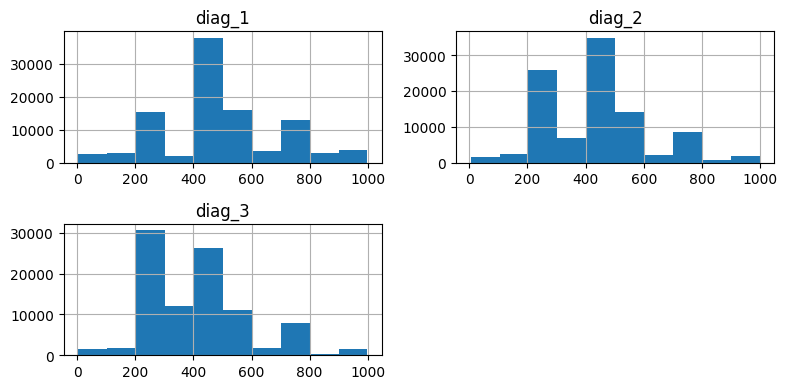

In [14]:
for col in diag_cols:
    numeric_converted = pd.to_numeric(X[col], errors='coerce')
    non_numeric_mask = numeric_converted.isnull() & X[col].notna()
    
    # Original variable: replace non-numeric with NaN
    X[col] = numeric_converted

# Plot histograms for the cleaned numerical variables
X[diag_cols].hist(figsize=(8, 4))
plt.tight_layout()
plt.show()

In [15]:
X[diag_cols].head()

,diag_1,diag_2,diag_3
0,250.83,NaN,NaN
1,276.00,250.01,255.0
2,648.00,250.00,NaN
3,8.00,250.43,403.0
4,197.00,157.00,250.0


## Missing data

Find datasets with missing data

In [16]:
for dataset in datasets.keys():
    X, y = load_data(dataset)
    if X.isnull().sum().sum() > 0:
        print(dataset)

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


diabetes130
sencom


(1567, 590)


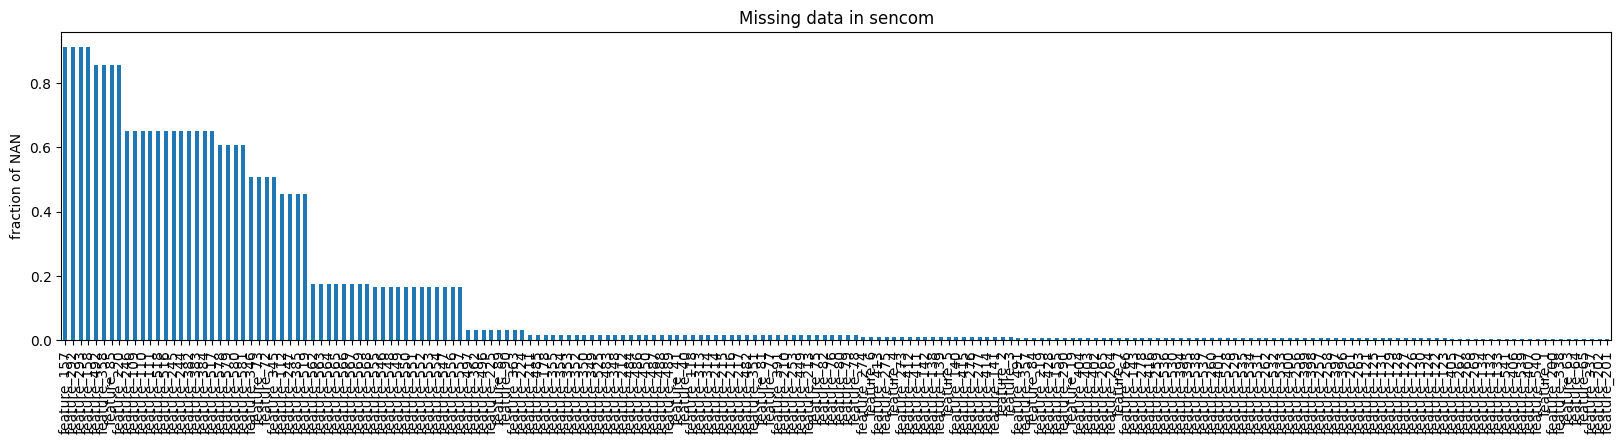

In [17]:
X, y = load_data("sencom")
print(X.shape)

X.isnull().mean().sort_values(ascending=False).head(200).plot(kind='bar', figsize=(20,4))
plt.title("Missing data in sencom")
plt.ylabel("fraction of NAN")
plt.show()

Sencom has several variables with a big proportion of missing values.

(101766, 47)


/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


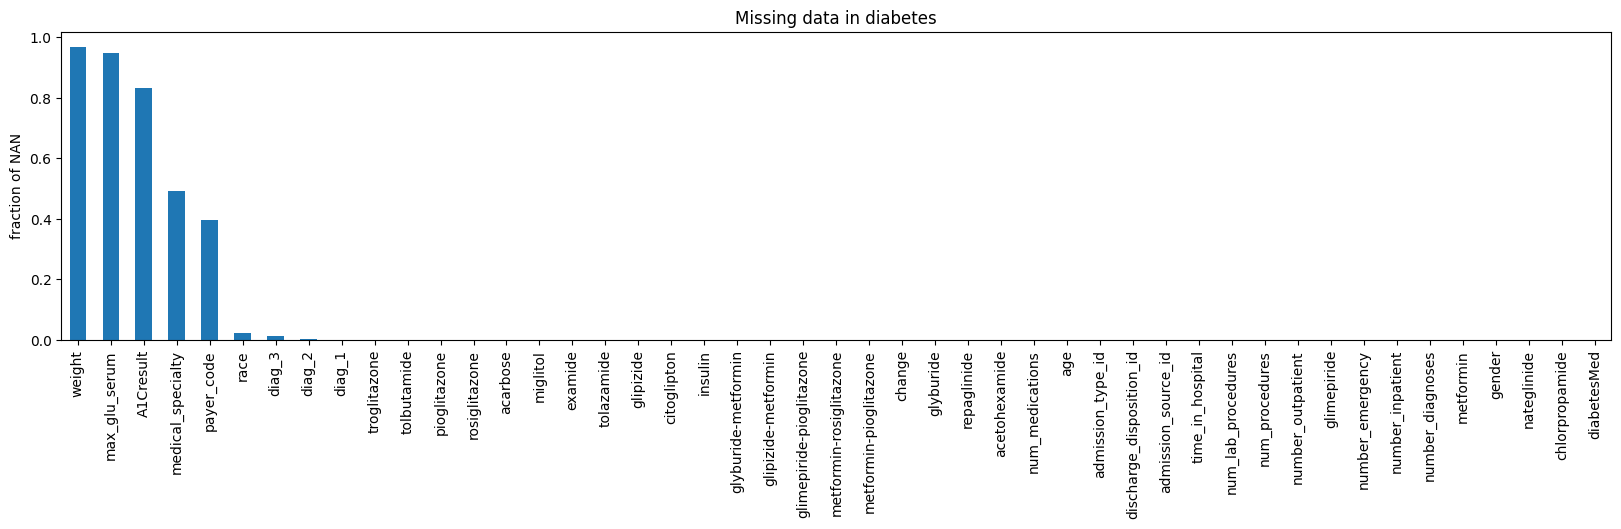

In [18]:
X, y = load_data("diabetes130")
print(X.shape)

X.isnull().mean().sort_values(ascending=False).plot(kind='bar', figsize=(20,4))
plt.title("Missing data in diabetes")
plt.ylabel("fraction of NAN")
plt.show()

In [19]:
# Get columns that have at least one NaN value
cols_with_nan = X.columns[X.isnull().sum() > 0]

# View those columns
X[cols_with_nan].head()

,race,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult
0,Caucasian,NaN,NaN,Pediatrics-Endocrinology,250.83,NaN,NaN,NaN,NaN
1,Caucasian,NaN,NaN,NaN,276,250.01,255,NaN,NaN
2,AfricanAmerican,NaN,NaN,NaN,648,250,V27,NaN,NaN
3,Caucasian,NaN,NaN,NaN,8,250.43,403,NaN,NaN
4,Caucasian,NaN,NaN,NaN,197,157,250,NaN,NaN


In [20]:
X["diag_1"].unique()

<StringArray>
['250.83',    '276',    '648',      '8',    '197',    '414',    '428',
    '398',    '434',  '250.7',
 ...
     '58',    '649',    '832',    '133',    '975',    '833',    '391',
    '690',     '10',    'V51']
Length: 717, dtype: str

In [21]:
# Get columns with NaN values
cols_with_nan = X.columns[X.isnull().sum() > 0]

# Separate into numerical and categorical
numerical_cols = X[cols_with_nan].select_dtypes(include=['number']).columns.tolist()
categorical_cols = X[cols_with_nan].select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns with NaN:")
print(numerical_cols)

print("\nCategorical columns with NaN:")
print(categorical_cols)

Numerical columns with NaN:
[]

Categorical columns with NaN:
['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']


/var/folders/n4/2v690vyd1rd0c0rjks_7_fhc0000gn/T/ipykernel_70098/502922186.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X[cols_with_nan].select_dtypes(include=['object', 'category']).columns.tolist()


Diabetes has a few variables with a big proportion of missing values.

## Constant variables

In [22]:
# Print datasets with constant features

for dataset in datasets.keys():
    X, y = load_data(dataset)
    sel = DropConstantFeatures().fit(X.fillna(0))
    if len(sel.features_to_drop_) > 0:
        print(dataset)
        print(sel.features_to_drop_)
        print()

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


diabetes130
['examide', 'citoglipton']

sencom
['feature_13', 'feature_52', 'feature_97', 'feature_141', 'feature_149', 'feature_178', 'feature_179', 'feature_186', 'feature_189', 'feature_190', 'feature_191', 'feature_192', 'feature_193', 'feature_194', 'feature_226', 'feature_229', 'feature_230', 'feature_231', 'feature_232', 'feature_233', 'feature_234', 'feature_235', 'feature_236', 'feature_237', 'feature_240', 'feature_241', 'feature_242', 'feature_243', 'feature_256', 'feature_257', 'feature_258', 'feature_259', 'feature_260', 'feature_261', 'feature_262', 'feature_263', 'feature_264', 'feature_265', 'feature_266', 'feature_276', 'feature_284', 'feature_313', 'feature_314', 'feature_315', 'feature_322', 'feature_325', 'feature_326', 'feature_327', 'feature_328', 'feature_329', 'feature_330', 'feature_364', 'feature_369', 'feature_370', 'feature_371', 'feature_372', 'feature_373', 'feature_374', 'feature_375', 'feature_378', 'feature_379', 'feature_380', 'feature_381', 'feature_3

In [23]:
# number of constant features in sencom
len(sel.features_to_drop_)

112

## Feature histograms

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


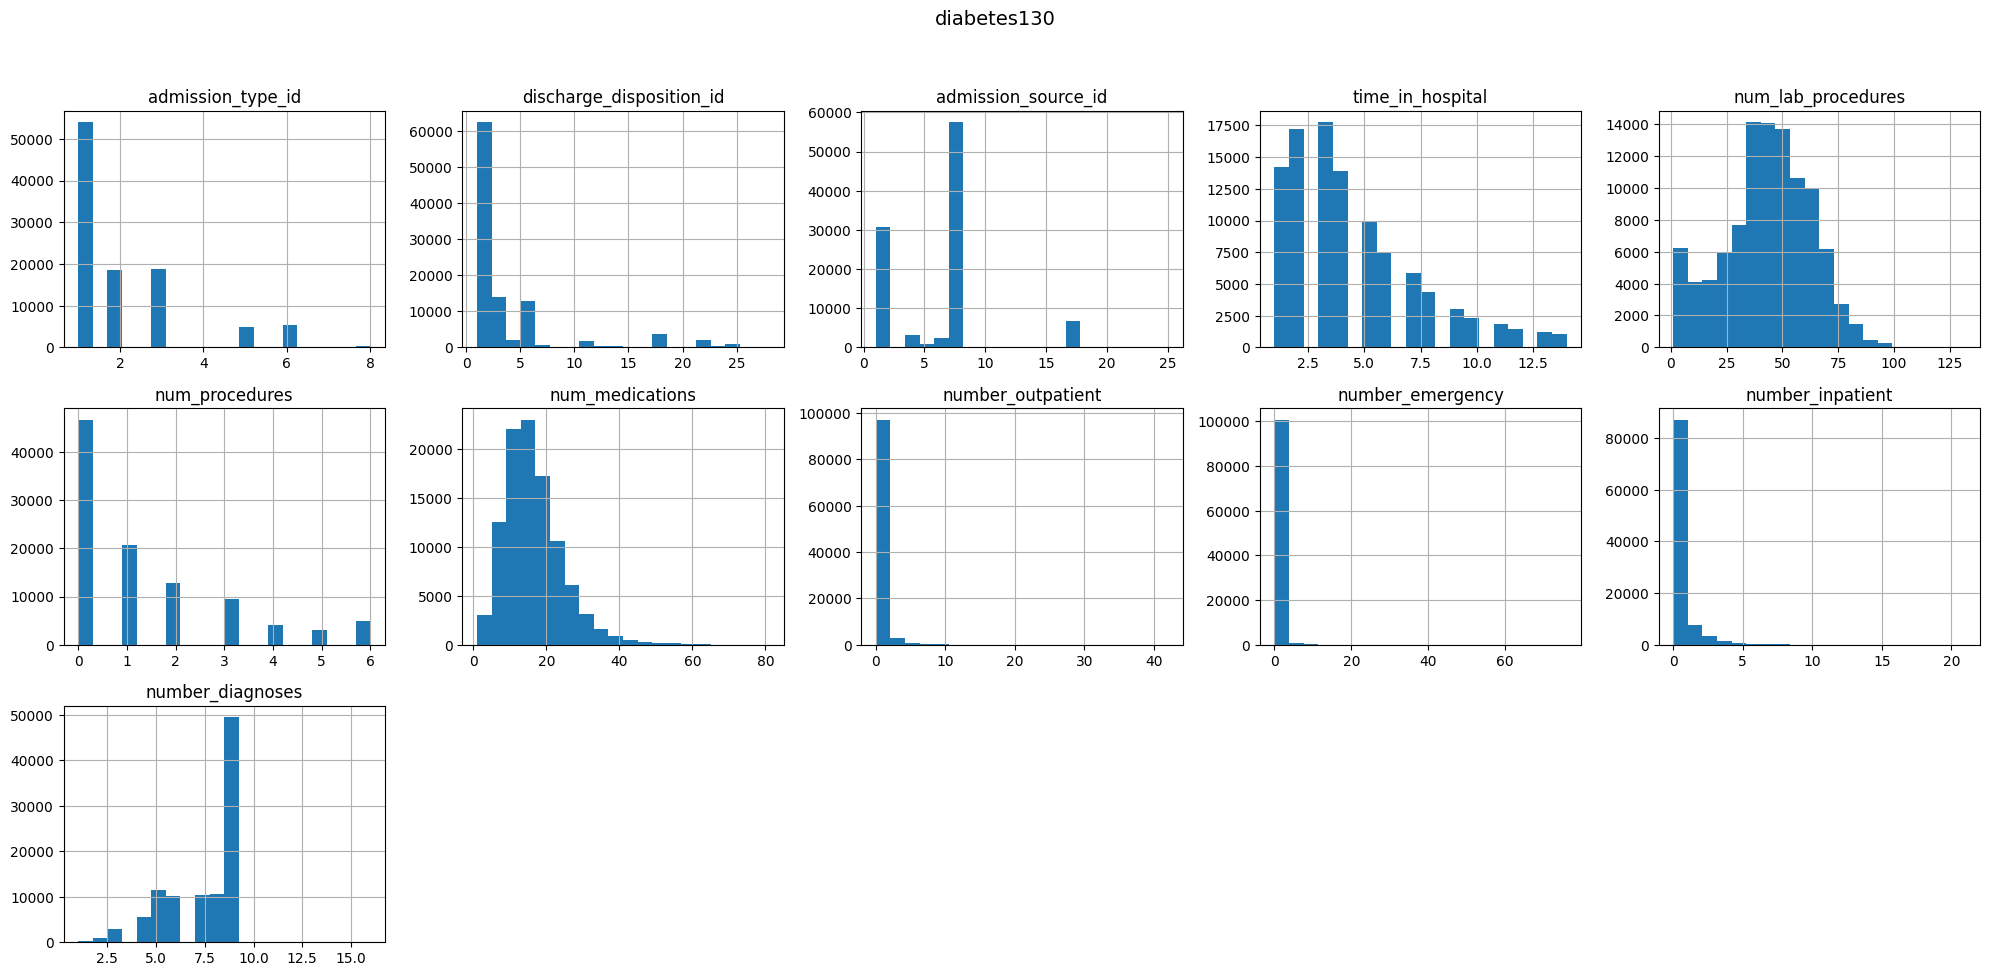

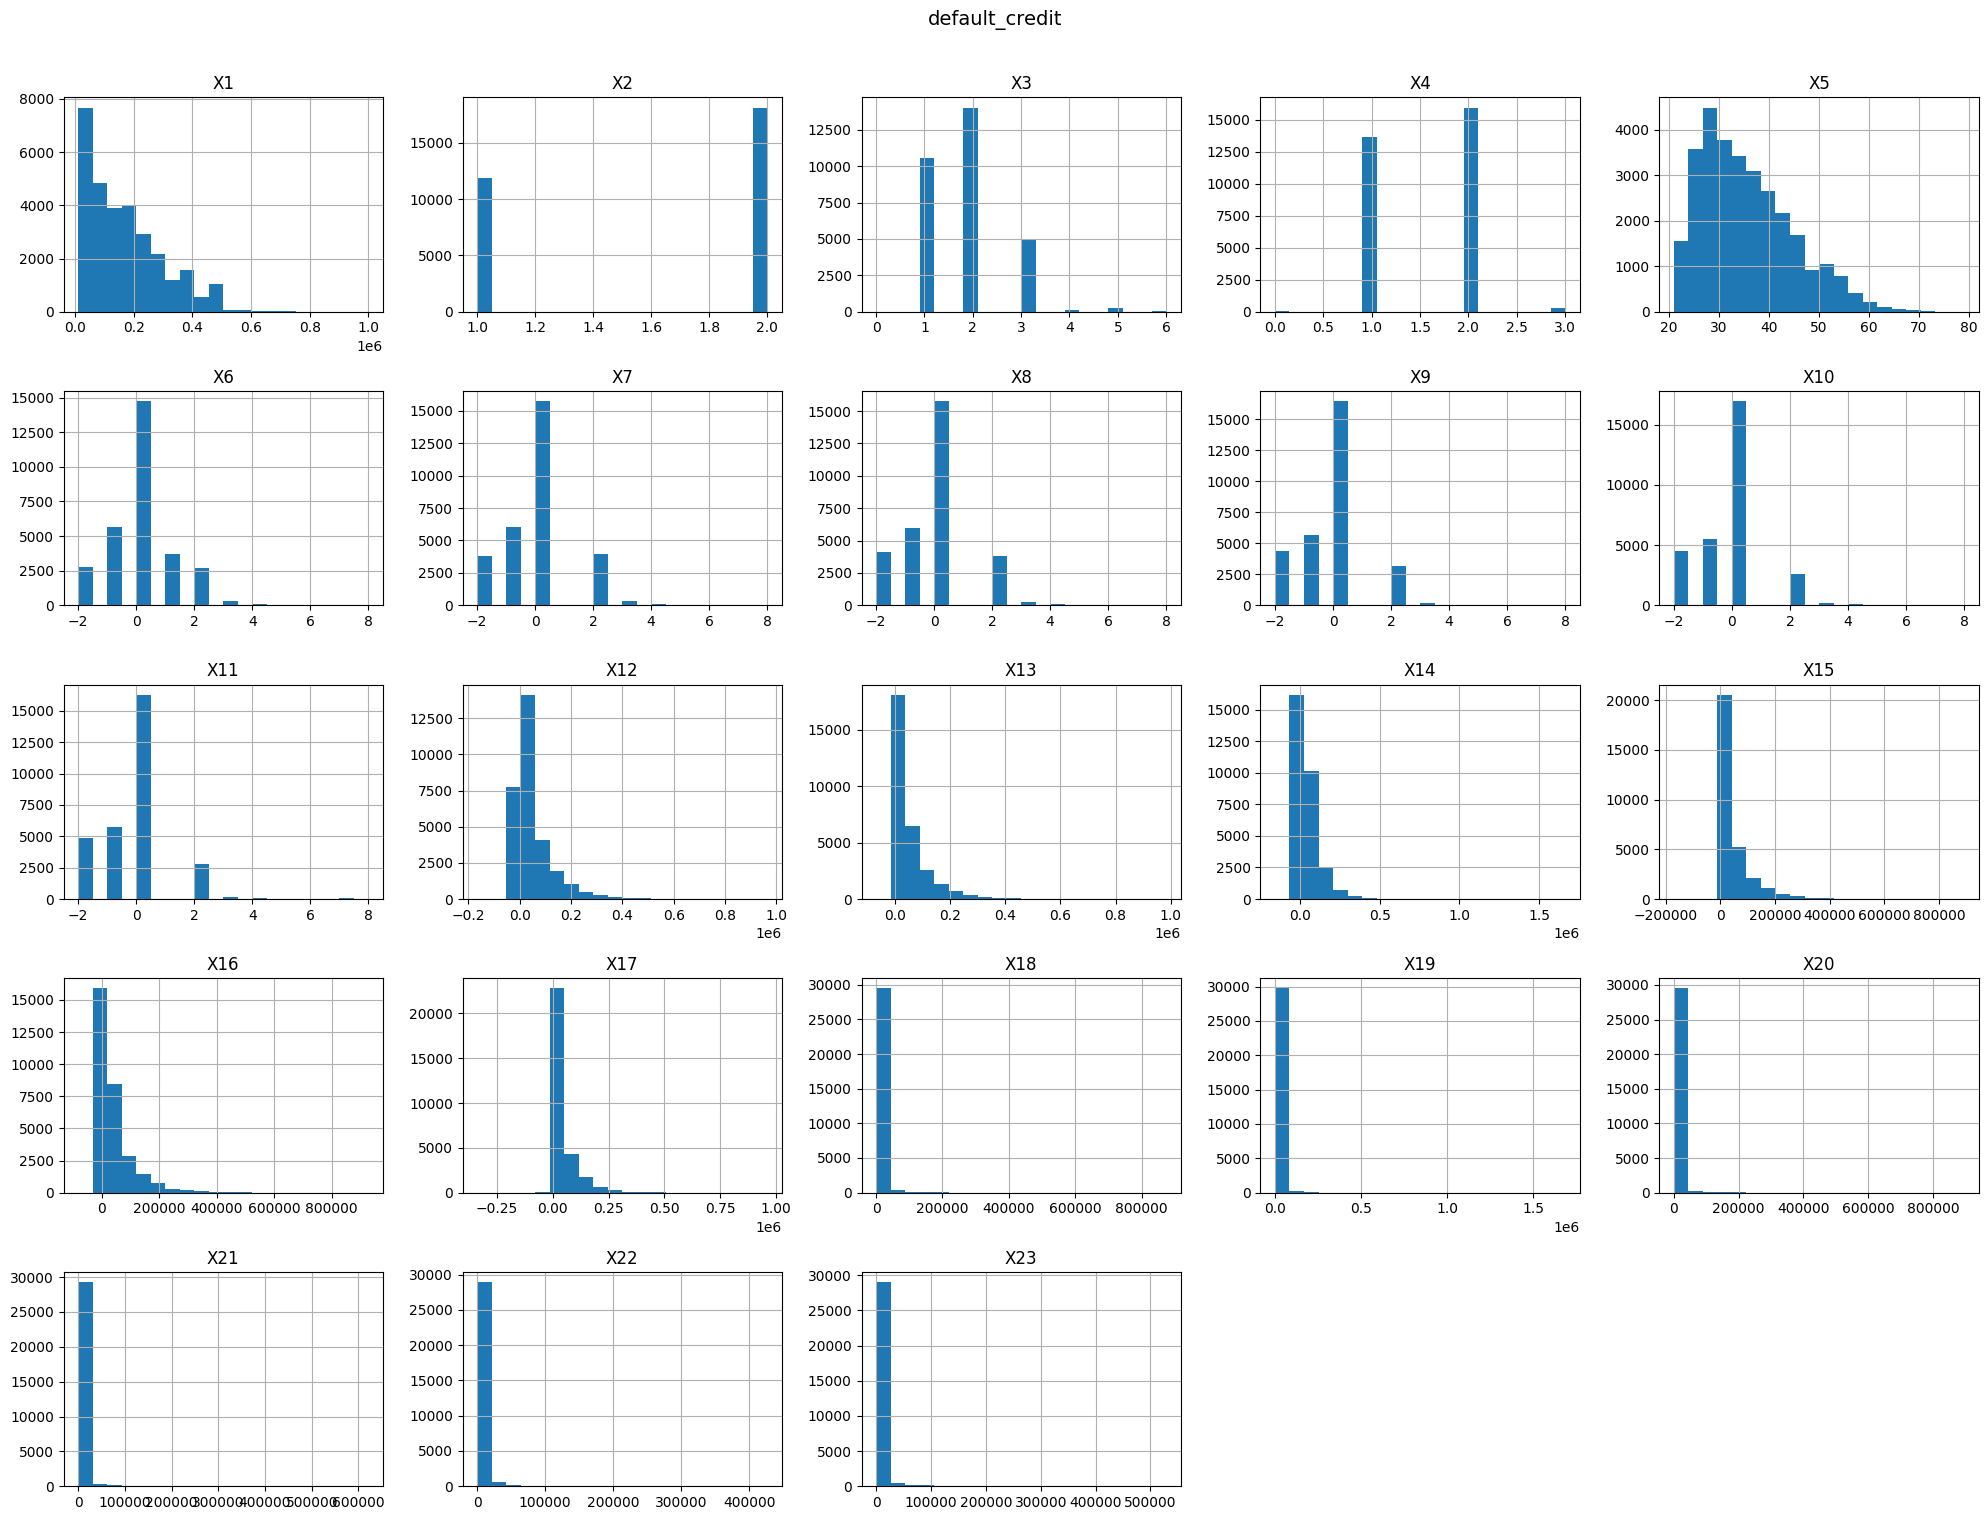

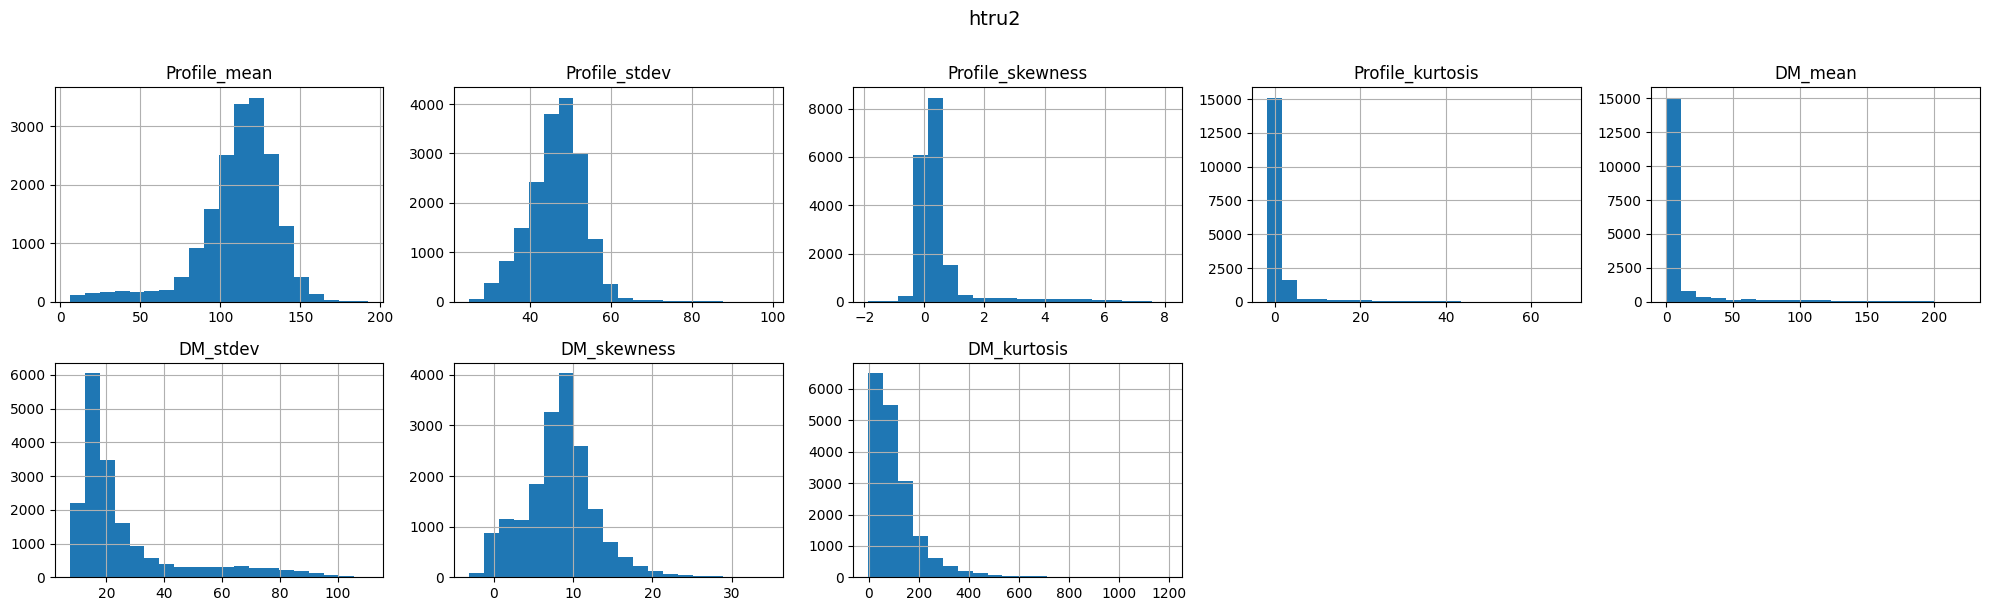

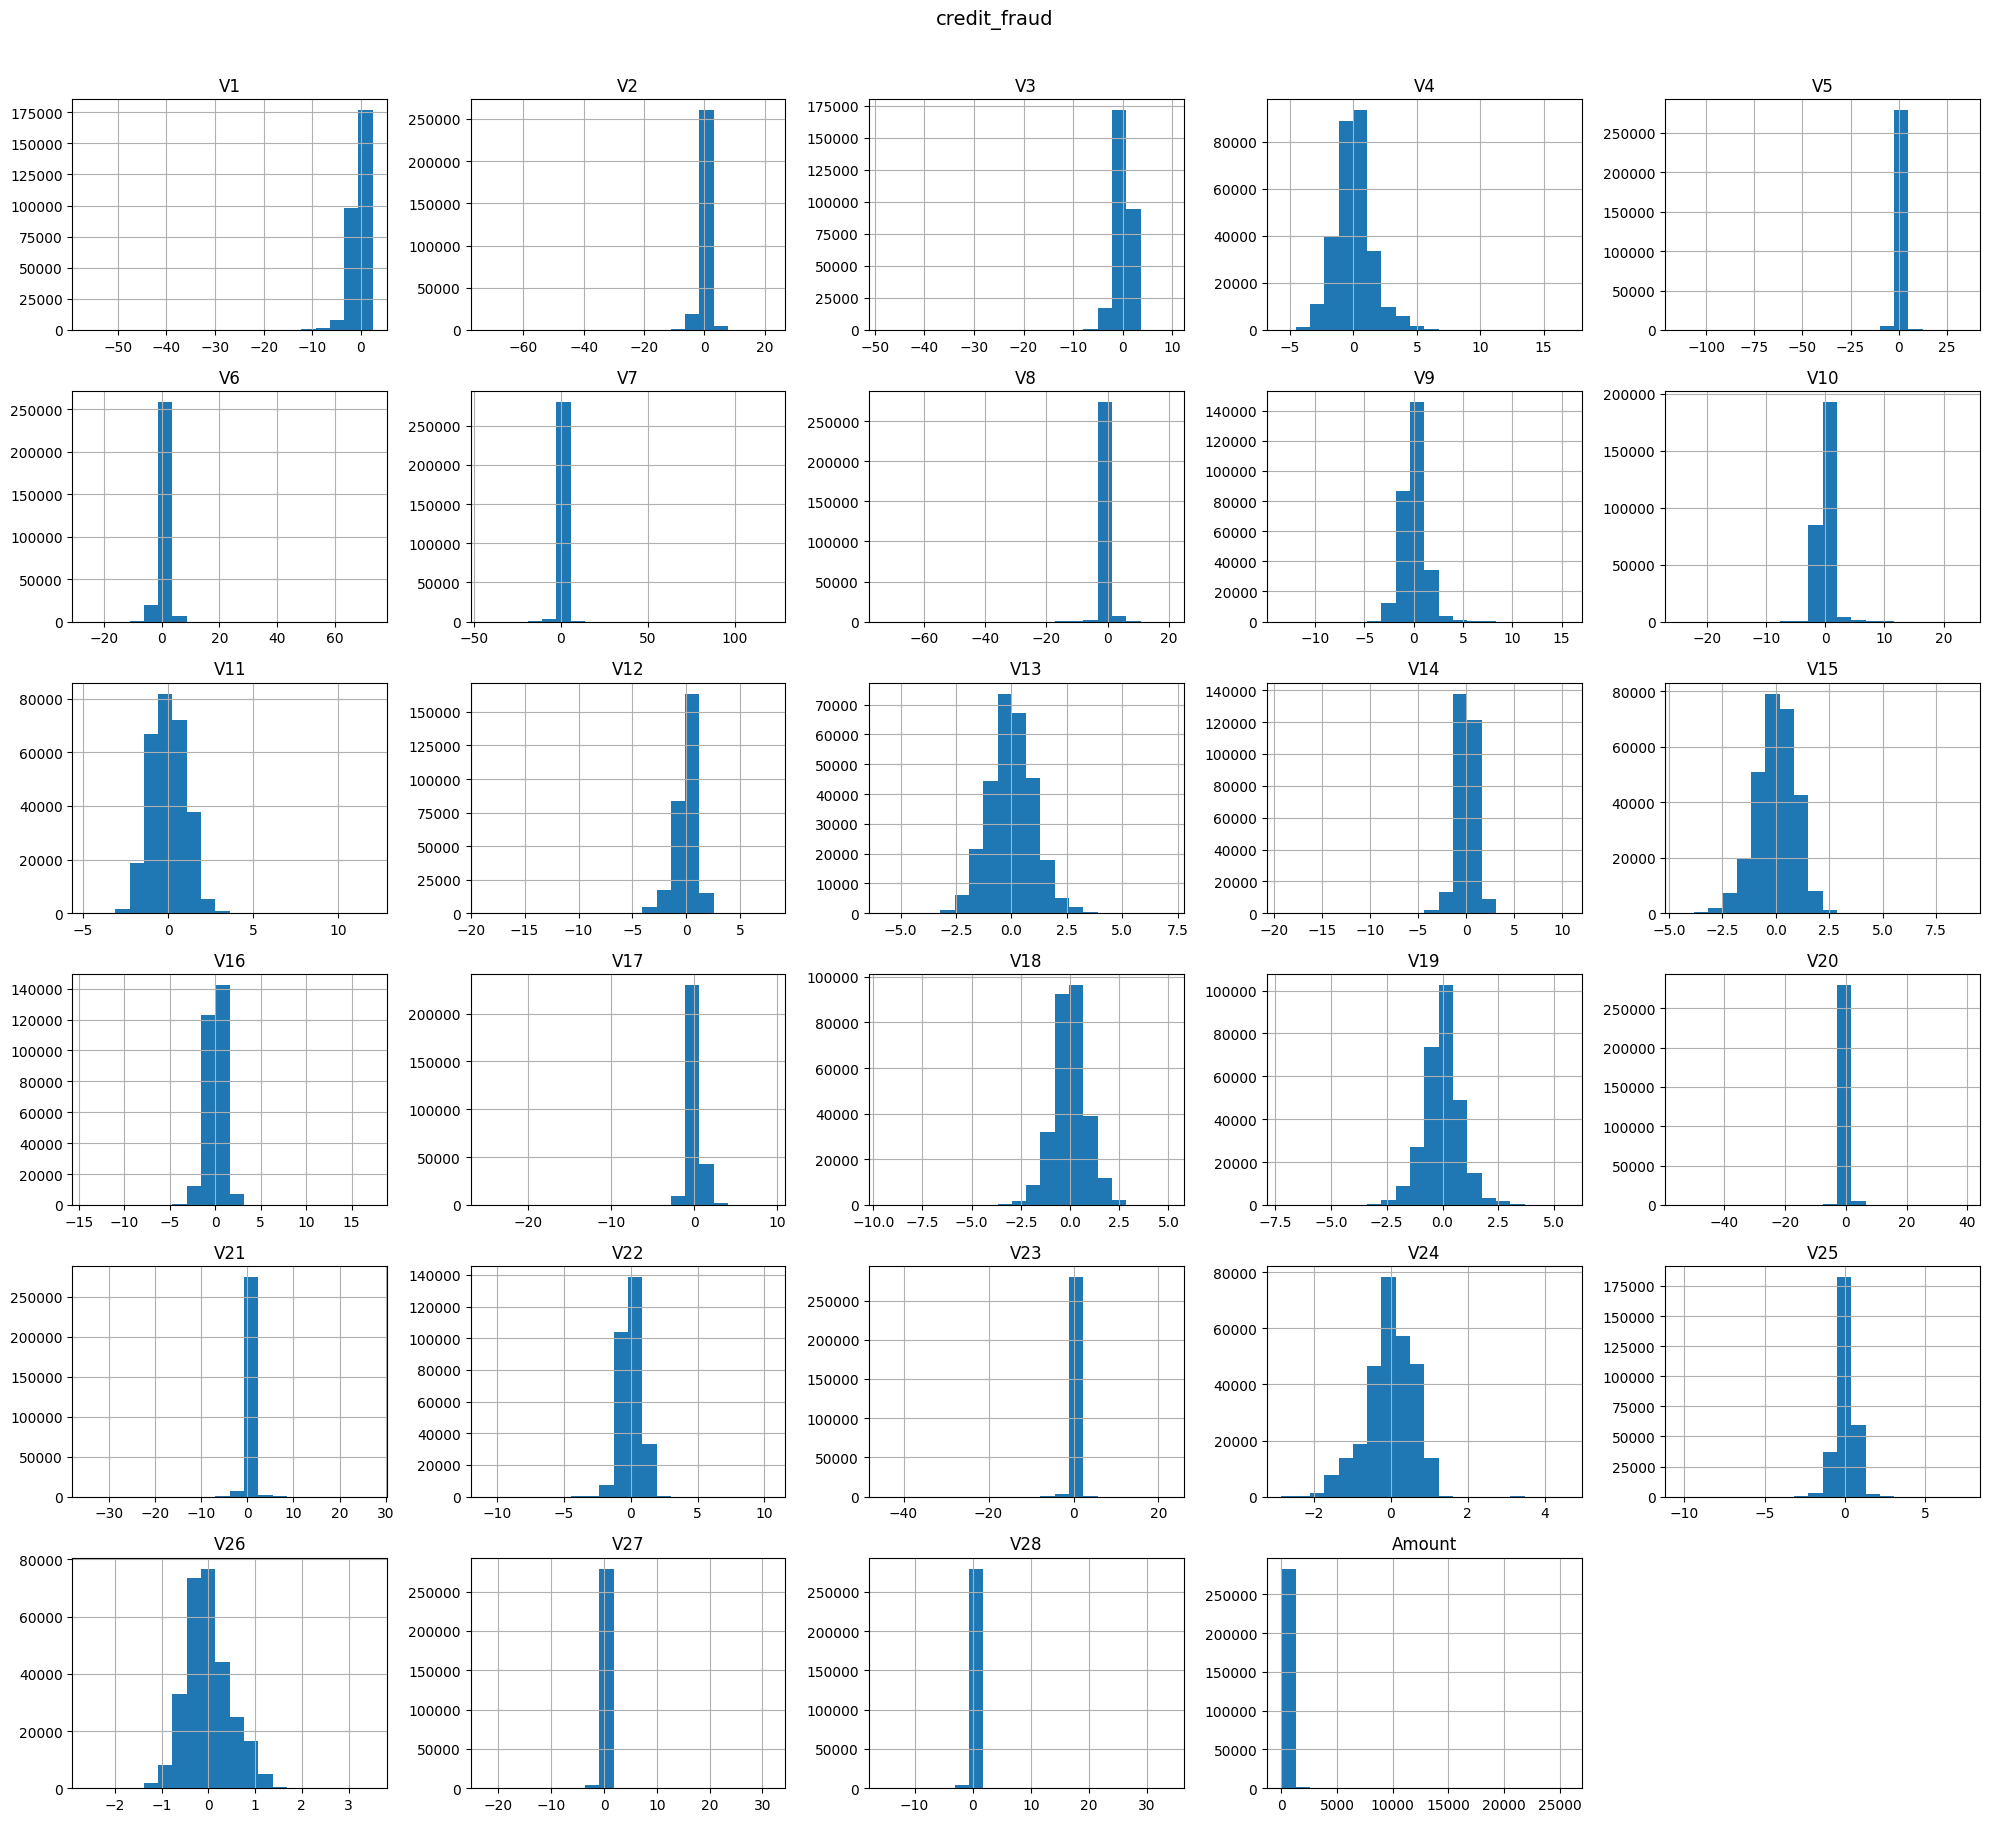

In [24]:
for dataset in datasets.keys():
    X, _ = load_data(dataset)
    
    n_features = X.shape[1]
    n_cols = 5
    n_rows = int(np.ceil(n_features / n_cols))
    
    pd.DataFrame(X).hist(bins=20, figsize=(4 * n_cols, 3 * n_rows), layout=(n_rows, n_cols))
    
    plt.suptitle(dataset, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"../../figures/datasets/{dataset}_features_hists.png", dpi=300, bbox_inches='tight')
    plt.show()